##1. Cíl experimentu
Název

Obarvování černobílých fotografií pomocí neuronových sítí

##Motivace

Automatické obarvování historických nebo černobílých fotografií představuje zajímavou úlohu počítačového vidění. Na rozdíl od klasické klasifikace není cílem přiřadit obrázku jednu kategorii, ale vytvořit nový obraz obsahující barevnou informaci. Model musí z černobílého vstupu odhadnout pravděpodobné barvy jednotlivých objektů a současně zachovat prostorovou strukturu fotografie.

Úloha je náročná zejména proto, že některé objekty mohou mít více možných barevných variant. Model proto musí využívat nejen lokální informaci jednotlivých pixelů, ale také kontext celého obrazu.

##Cíl experimentu

Cílem experimentu je navrhnout a natrénovat neuronovou síť, která bude schopna převést černobílou fotografii na barevnou.

Vstupem modelu bude jasová složka L v barevném prostoru LAB. Výstupem budou barevné složky A a B, které společně s původním jasem vytvoří výsledný barevný obraz.

Pro řešení úlohy byla zvolena konvoluční architektura typu U-Net. Tento typ sítě je vhodný pro image-to-image úlohy, protože dokáže zachovat prostorovou strukturu obrazu a současně využívat lokální i globální kontext. Detailní popis architektury je uveden v samostatné části notebooku.

##Očekávané výstupy

Na konci experimentu budou porovnány:

původní barevná fotografie,
černobílý vstup,
fotografie obarvená neuronovou sítí.

Kvalita bude hodnocena pomocí metrik MSE a MAE a také vizuálním porovnáním výsledků na deseti testovacích fotografiích.

##2. Načtení a vizualizace dat
Popis dat

Pro trénování modelu byly použity barevné fotografie, které byly následně převedeny do barevného prostoru LAB. Každý obrázek byl před zpracováním zmenšen na rozlišení 32 × 32 pixelů, aby bylo možné efektivně trénovat model v prostředí Google Colab.

Barevný prostor LAB byl zvolen proto, že odděluje jasovou složku od barevné informace. Jasová složka L obsahuje informaci o intenzitě světla, zatímco složky A a B reprezentují barevnou informaci.

V rámci experimentu bude jasová složka L použita jako vstup neuronové sítě a složky A a B budou představovat cílové hodnoty, které se model naučí predikovat.

##Předzpracování dat

Před samotným trénováním byly provedeny následující kroky:

Načtení barevných fotografií.
Změna na velikosti obrázků na 32 × 32 pixelů.
Převod z RGB do barevného prostoru LAB.
Oddělení vstupní složky L a cílových složek A a B.
Normalizace hodnot pro stabilnější trénování neuronové sítě.
Vizualizace dat

Pro ověření správnosti předzpracování byly zobrazeny:

původní RGB fotografie,
jasová složka L,
barevná složka A,
barevná složka B.

Vizualizace umožňuje ověřit, že jasová informace je zachována ve vstupu a barevná informace je skutečně obsažena pouze ve výstupních kanálech.

In [1]:
# =========================
# 1. Import knihoven
# =========================

import torch
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets import CIFAR10
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt

from skimage.color import rgb2lab, lab2rgb

In [2]:
# =========================
# 2. Nastavení zařízení
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Použité zařízení:", device)

Použité zařízení: cpu


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

print(os.listdir('/content/drive/MyDrive/Colab Notebooks'))

['W1.ipynb', 'W2.ipynb', 'archive.zip', 'Kopie sešitu Untitled0.ipynb', 'WS_1_OJ.ipynb', 'Kopie sešitu WS_4_OJ (1).ipynb', 'Kopie sešitu WS_4_OJ.ipynb', ' WS_2_OJ.ipynb', 'WS_3_OJ.ipynb']


In [5]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Colab Notebooks/archive.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print("Počet souborů:", len(zip_ref.namelist()))

    print("\nPrvních 20 položek:")
    for f in zip_ref.namelist()[:20]:
        print(f)

Počet souborů: 9

Prvních 20 položek:
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_1
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-python.tar.gz


In [6]:
# =========================
# 3. Kontrola CIFAR
# =========================

import zipfile
import os

zip_path = "/content/drive/MyDrive/Colab Notebooks/archive.zip"
extract_path = "/content/cifar"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Rozbaleno do:", extract_path)

Rozbaleno do: /content/cifar


In [7]:
import os

print(os.listdir("/content/cifar"))

['cifar-10-python.tar.gz', 'cifar-10-batches-py']


In [8]:
# =========================
# Reprodukovatelnost experimentu
# =========================

import random
import numpy as np
import torch

SEED = 27

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Seed nastaven na {SEED}")

Seed nastaven na 27


In [9]:
# =========================
# Načtení CIFAR-10
# =========================

from torchvision.datasets import CIFAR10
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

train_full = CIFAR10(
    root="/content/cifar",
    train=True,
    download=False,
    transform=transform
)

test_full = CIFAR10(
    root="/content/cifar",
    train=False,
    download=False,
    transform=transform
)

print("Train:", len(train_full))
print("Test:", len(test_full))

Train: 50000
Test: 10000


In [48]:
# =========================
# Výběr podvzorku
# =========================

from torch.utils.data import Subset

train_indices = np.random.choice(
    len(train_full),
    size=2200,
    replace=False
)

test_indices = np.random.choice(
    len(test_full),
    size=200,
    replace=False
)

train_raw = Subset(
    train_full,
    train_indices[:2000]
)

valid_raw = Subset(
    train_full,
    train_indices[2000:]
)

test_raw = Subset(
    test_full,
    test_indices
)

print("Train:", len(train_raw))
print("Validation:", len(valid_raw))
print("Test:", len(test_raw))

Train: 2000
Validation: 200
Test: 200


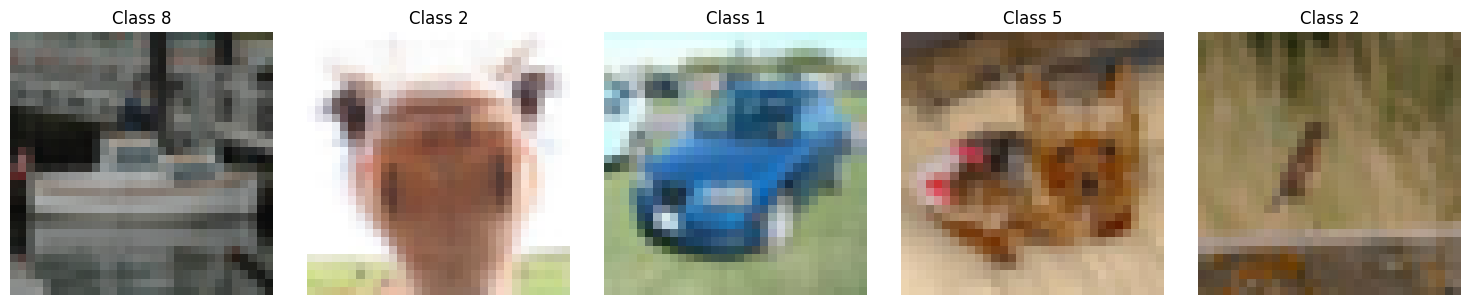

In [49]:
# =========================
# Vizualizace 5 obrázků
# =========================

import matplotlib.pyplot as plt
import random

random.seed(SEED)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

indices = random.sample(range(len(train_raw)), 5)

for ax, idx in zip(axes, indices):

    image, label = train_raw[idx]

    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(f"Class {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Pro ověření správného načtení datasetu bylo náhodně zobrazeno několik obrázků z trénovací množiny. Vizualizace slouží ke kontrole kvality dat před jejich dalším zpracováním.

In [50]:
# =========================
# Dataset pro colorization
# =========================

from torch.utils.data import Dataset
from skimage.color import rgb2lab
import numpy as np
import torch

class ColorizationDataset(Dataset):

    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image, _ = self.dataset[idx]

        image = image.permute(1, 2, 0).numpy()

        lab = rgb2lab(image).astype(np.float32)

        L = lab[:, :, 0:1] / 100.0
        AB = lab[:, :, 1:3] / 128.0

        L = torch.from_numpy(L).permute(2, 0, 1)
        AB = torch.from_numpy(AB).permute(2, 0, 1)

        return L, AB

In [51]:
train_dataset = ColorizationDataset(train_raw)
valid_dataset = ColorizationDataset(valid_raw)
test_dataset = ColorizationDataset(test_raw)

print("Train:", len(train_dataset))
print("Validation:", len(valid_dataset))
print("Test:", len(test_dataset))

Train: 2000
Validation: 200
Test: 200


In [52]:
L, AB = train_dataset[0]

print("L shape :", L.shape)
print("AB shape:", AB.shape)

L shape : torch.Size([1, 32, 32])
AB shape: torch.Size([2, 32, 32])


In [53]:
# =========================
# DataLoadery
# =========================

from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))
print("Test batches:", len(test_loader))

Train batches: 125
Validation batches: 13
Test batches: 13


In [54]:
# Kontrola jednoho batche

L_batch, AB_batch = next(iter(train_loader))

print("L batch shape :", L_batch.shape)
print("AB batch shape:", AB_batch.shape)

L batch shape : torch.Size([16, 1, 32, 32])
AB batch shape: torch.Size([16, 2, 32, 32])


### Kontrola DataLoaderu

Pro ověření správné funkce DataLoaderu byl zobrazen tvar jedné dávky dat.

Výstup potvrzuje, že DataLoader vrací dávky o velikosti 16 obrázků. Vstup modelu tvoří jasová složka L o rozměrech [16, 1, 32, 32] a cílové hodnoty tvoří barevné složky A a B o rozměrech [16, 2, 32, 32].

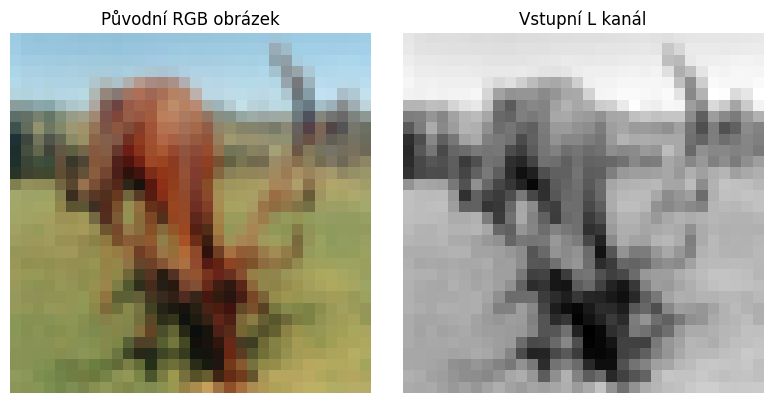

In [55]:
# =========================
# Vizualizace RGB vs L kanál
# =========================

L_batch, AB_batch = next(iter(train_loader))

# původní obrázek z train_raw
rgb_img, _ = train_raw[0]

# L kanál z ColorizationDataset
L_img, _ = train_dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# RGB
axes[0].imshow(rgb_img.permute(1, 2, 0))
axes[0].set_title("Původní RGB obrázek")
axes[0].axis("off")

# L kanál
axes[1].imshow(
    L_img.squeeze().numpy(),
    cmap="gray"
)
axes[1].set_title("Vstupní L kanál")
axes[1].axis("off")

plt.tight_layout()
plt.show()

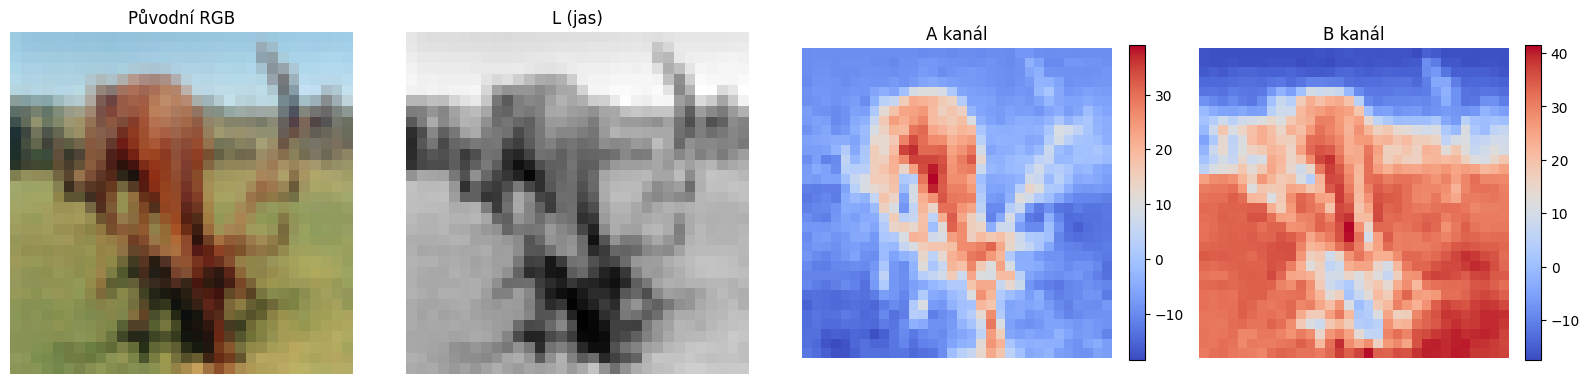

In [56]:
# =========================
# Vizualizace RGB -> LAB
# =========================

from skimage.color import rgb2lab
import matplotlib.pyplot as plt
import numpy as np

# vyber jeden obrázek
rgb_img, _ = train_raw[0]

# Tensor -> NumPy
rgb_np = rgb_img.permute(1, 2, 0).numpy()

# RGB -> LAB
lab = rgb2lab(rgb_np)

L = lab[:, :, 0]
A = lab[:, :, 1]
B = lab[:, :, 2]

# vykreslení
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(rgb_np)
axes[0].set_title("Původní RGB")
axes[0].axis("off")

axes[1].imshow(L, cmap="gray")
axes[1].set_title("L (jas)")
axes[1].axis("off")

im2 = axes[2].imshow(A, cmap="coolwarm")
axes[2].set_title("A kanál")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

im3 = axes[3].imshow(B, cmap="coolwarm")
axes[3].set_title("B kanál")
axes[3].axis("off")
plt.colorbar(im3, ax=axes[3], fraction=0.046)

plt.tight_layout()
plt.show()

### Vizualizace RGB → LAB

Obrázek byl převeden z RGB do barevného prostoru LAB.

- Kanál L obsahuje jasovou informaci a představuje vstup neuronové sítě.
- Kanály A a B obsahují barevnou informaci a představují cílové hodnoty, které se model učí predikovat.

Z obrázku je patrné, že většina strukturální informace je zachována v kanálu L, zatímco kanály A a B nesou informaci o barevnosti jednotlivých objektů.

## 3. Baseline modely

Před návrhem finální architektury byly definovány jednoduché referenční modely (baseline), které budou sloužit pro porovnání s architekturou U-Net.

Byly zvoleny dva baseline přístupy:

1. Mean Color Baseline – každý obrázek je obarven průměrnou barvou.

2. Simple CNN – jednoduchá konvoluční neuronová síť bez encoder-decoder struktury.

Tyto modely představují minimální referenční úroveň, kterou by měl finální model překonat.

In [57]:
# =========================
# 3.1 Mean Color Baseline
# =========================

import torch
import torch.nn.functional as F

def mean_color_baseline(L, AB_true):
    """
    Mean Color Baseline

    Pro každý obrázek spočítá průměrnou hodnotu kanálů A a B
    a touto průměrnou barvou vyplní celý obrázek.

    L:       tensor [B, 1, H, W]
    AB_true: tensor [B, 2, H, W]

    return: predikované AB kanály [B, 2, H, W]
    """

    mean_ab = AB_true.mean(dim=(2, 3), keepdim=True)
    pred_ab = mean_ab.expand_as(AB_true)

    return pred_ab

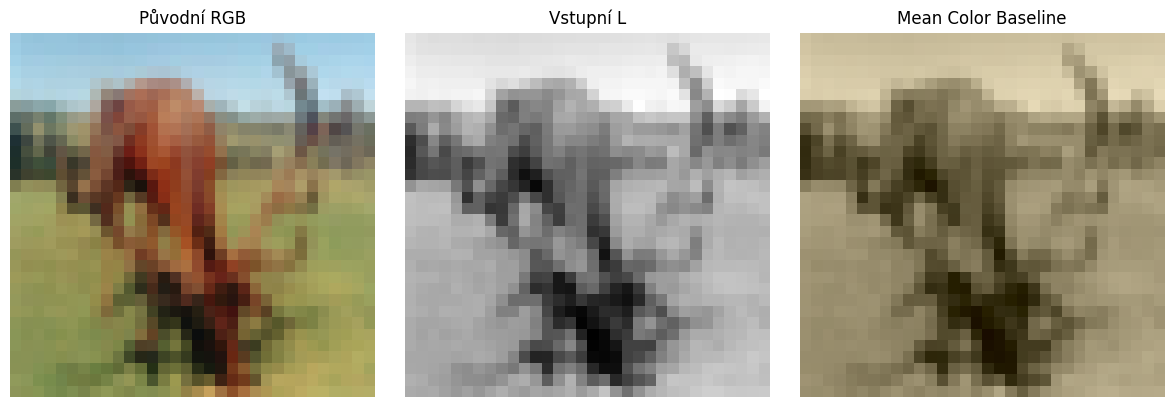

In [58]:
# =========================
# Vizualizace Mean Color Baseline
# =========================

from skimage.color import lab2rgb
import numpy as np

# jeden vzorek
L, AB_true = train_dataset[0]

# přidání batch dimenze
L_batch = L.unsqueeze(0)
AB_batch = AB_true.unsqueeze(0)

# baseline predikce
AB_pred = mean_color_baseline(
    L_batch,
    AB_batch
)

# převod zpět na numpy
L_np = L.squeeze().numpy() * 100

AB_true_np = (
    AB_true.permute(1,2,0).numpy() * 128
)

AB_pred_np = (
    AB_pred.squeeze().permute(1,2,0).numpy() * 128
)

# rekonstrukce RGB
lab_true = np.dstack([L_np, AB_true_np])
lab_pred = np.dstack([L_np, AB_pred_np])

rgb_true = lab2rgb(lab_true)
rgb_pred = lab2rgb(lab_pred)

# vykreslení
fig, axes = plt.subplots(1,3, figsize=(12,4))

axes[0].imshow(rgb_true)
axes[0].set_title("Původní RGB")
axes[0].axis("off")

axes[1].imshow(L_np, cmap="gray")
axes[1].set_title("Vstupní L")
axes[1].axis("off")

axes[2].imshow(rgb_pred)
axes[2].set_title("Mean Color Baseline")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Interpretace výsledku

Mean Color Baseline používá pouze průměrnou barvu obrázku a nerozlišuje jednotlivé objekty. Výsledný obraz proto postrádá lokální barevné detaily a slouží pouze jako referenční úroveň pro porovnání s neuronovými sítěmi.

#Úvaha

Přestože Mean Color Baseline využívá informaci ze skutečných barevných kanálů A a B, nelze ji považovat za zcela nereálný referenční přístup. Při ručním obarvování historických fotografií by člověk pravděpodobně také vycházel z podobných barevných referencí, například z jiných fotografií stejného objektu, období nebo prostředí. Baseline tak do určité míry simuluje situaci, kdy je k dispozici externí znalost o typických barvách dané scény.

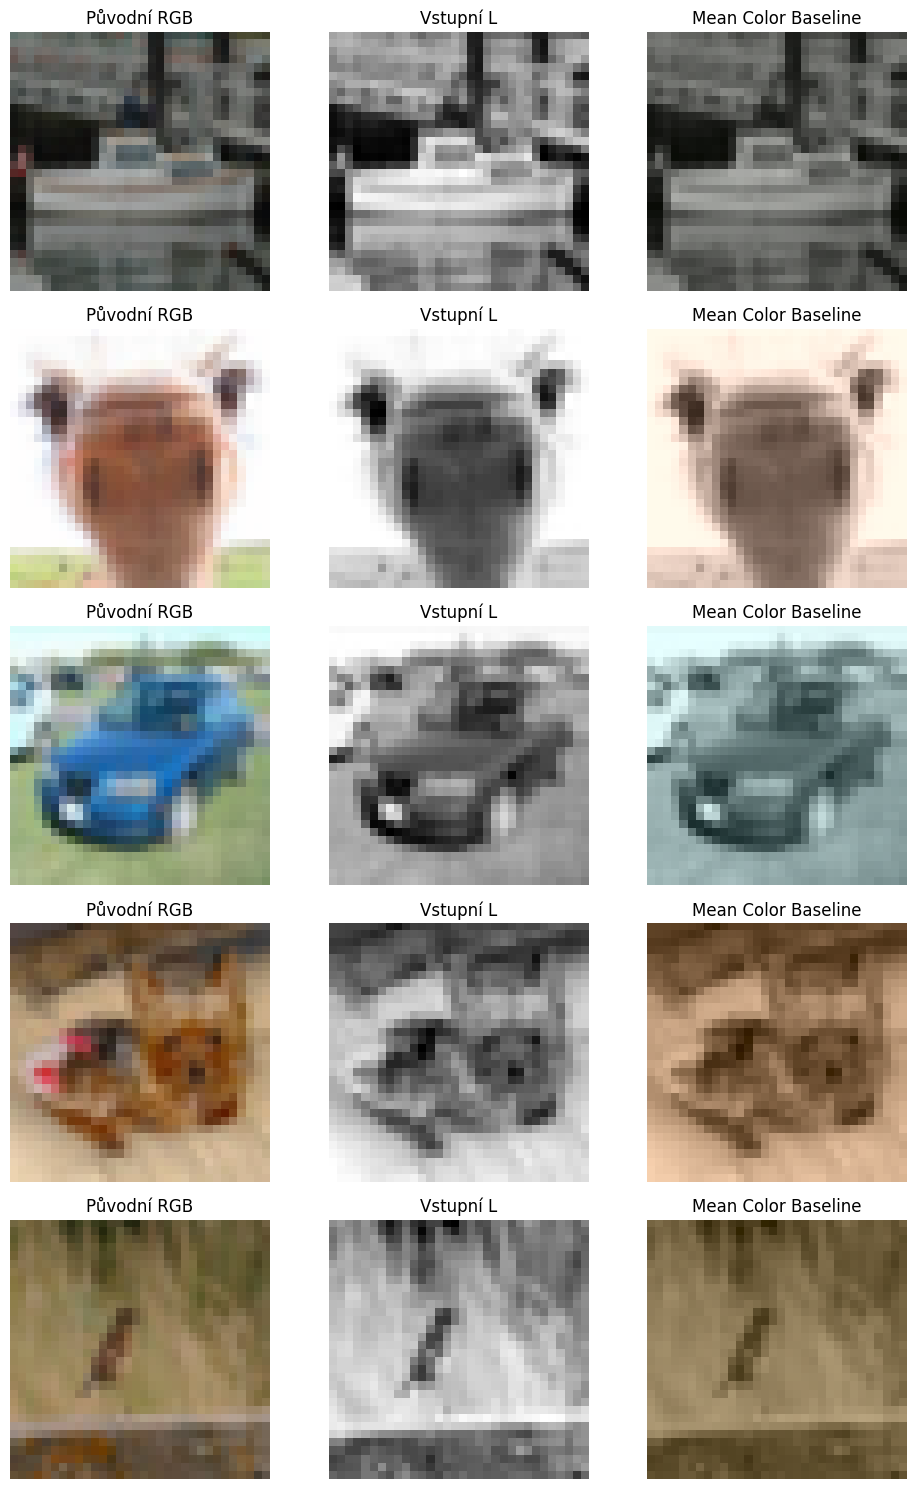

In [59]:
# =========================
# Mean Color Baseline
# 5 ukázkových obrázků
# =========================

from skimage.color import lab2rgb
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(SEED)

indices = random.sample(
    range(len(train_dataset)),
    5
)

fig, axes = plt.subplots(
    5, 3,
    figsize=(10, 15)
)

for row, idx in enumerate(indices):

    # načtení vzorku
    L, AB_true = train_dataset[idx]

    # batch dimenze
    L_batch = L.unsqueeze(0)
    AB_batch = AB_true.unsqueeze(0)

    # baseline predikce
    AB_pred = mean_color_baseline(
        L_batch,
        AB_batch
    )

    # převod do numpy
    L_np = L.squeeze().numpy() * 100

    AB_true_np = (
        AB_true
        .permute(1,2,0)
        .numpy() * 128
    )

    AB_pred_np = (
        AB_pred
        .squeeze()
        .permute(1,2,0)
        .numpy() * 128
    )

    # LAB -> RGB
    lab_true = np.dstack([
        L_np,
        AB_true_np
    ])

    lab_pred = np.dstack([
        L_np,
        AB_pred_np
    ])

    rgb_true = lab2rgb(lab_true)
    rgb_pred = lab2rgb(lab_pred)

    # vykreslení
    axes[row,0].imshow(rgb_true)
    axes[row,0].set_title("Původní RGB")
    axes[row,0].axis("off")

    axes[row,1].imshow(
        L_np,
        cmap="gray"
    )
    axes[row,1].set_title("Vstupní L")
    axes[row,1].axis("off")

    axes[row,2].imshow(rgb_pred)
    axes[row,2].set_title("Mean Color Baseline")
    axes[row,2].axis("off")

plt.tight_layout()
plt.show()

### Simple CNN Baseline

Simple CNN Baseline je jednoduchý trénovatelný model. Na rozdíl od Mean Color Baseline již využívá lokální okolí pixelů pomocí konvolučních vrstev.

Tento model ale nemá encoder-decoder strukturu ani skip connections. Proto slouží jako jednoduchá referenční architektura pro porovnání s U-Netem.

In [60]:
# =========================
# 3.2 Simple CNN Baseline
# =========================

import torch.nn as nn

class SimpleCNN(nn.Module):
    """
    Jednoduchá konvoluční síť pro predikci A/B kanálů.

    Vstup:  L kanál [B, 1, 32, 32]
    Výstup: A/B kanály [B, 2, 32, 32]
    """

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 2, kernel_size=1)
        )

    def forward(self, x):
        return self.net(x)

In [61]:
# =========================
# Inicializace Simple CNN
# =========================

simple_cnn = SimpleCNN().to(device)

print(simple_cnn)

SimpleCNN(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 2, kernel_size=(1, 1), stride=(1, 1))
  )
)


In [62]:
# =========================
# Test průchodu modelem
# =========================

L_batch, AB_batch = next(iter(train_loader))

L_batch = L_batch.to(device)

pred_AB = simple_cnn(L_batch)

print("Input :", L_batch.shape)
print("Output:", pred_AB.shape)

Input : torch.Size([16, 1, 32, 32])
Output: torch.Size([16, 2, 32, 32])


In [63]:
# =========================
# Trénovací funkce
# =========================

import torch.optim as optim

criterion = nn.MSELoss()

def train_model(
    model,
    train_loader,
    valid_loader,
    epochs=30,
    lr=1e-3,
    patience=10
):

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    train_losses = []
    valid_losses = []

    best_valid_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):

        # TRAIN
        model.train()

        running_loss = 0.0

        for L, AB in train_loader:

            L = L.to(device)
            AB = AB.to(device)

            optimizer.zero_grad()

            pred_AB = model(L)

            loss = criterion(
                pred_AB,
                AB
            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        train_loss = (
            running_loss /
            len(train_loader)
        )

        train_losses.append(train_loss)

        # VALIDATION
        model.eval()

        running_loss = 0.0

        with torch.no_grad():

            for L, AB in valid_loader:

                L = L.to(device)
                AB = AB.to(device)

                pred_AB = model(L)

                loss = criterion(
                    pred_AB,
                    AB
                )

                running_loss += loss.item()

        valid_loss = (
            running_loss /
            len(valid_loader)
        )

        valid_losses.append(valid_loss)

        # Uložení nejlepšího modelu
        if valid_loss < best_valid_loss:

            best_valid_loss = valid_loss

            best_model_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train: {train_loss:.4f} | "
            f"Valid: {valid_loss:.4f}"
        )

        # Early stopping
        if epochs_without_improvement >= patience:

            print(
                f"Early stopping po {epoch+1} epochách."
            )

            break

    # Načtení nejlepšího modelu
    if best_model_state is not None:

        model.load_state_dict(
            best_model_state
        )

    print(
        f"Nejlepší validační loss: "
        f"{best_valid_loss:.4f}"
    )

    return train_losses, valid_losses

In [64]:
train_losses, valid_losses = train_model(
    simple_cnn,
    train_loader,
    valid_loader,
    epochs=50,
    lr=0.001
)

Epoch 1/50 | Train: 0.0114 | Valid: 0.0109
Epoch 2/50 | Train: 0.0111 | Valid: 0.0108
Epoch 3/50 | Train: 0.0110 | Valid: 0.0109
Epoch 4/50 | Train: 0.0110 | Valid: 0.0108
Epoch 5/50 | Train: 0.0110 | Valid: 0.0107
Epoch 6/50 | Train: 0.0110 | Valid: 0.0110
Epoch 7/50 | Train: 0.0109 | Valid: 0.0108
Epoch 8/50 | Train: 0.0110 | Valid: 0.0108
Epoch 9/50 | Train: 0.0109 | Valid: 0.0107
Epoch 10/50 | Train: 0.0109 | Valid: 0.0107
Epoch 11/50 | Train: 0.0109 | Valid: 0.0108
Epoch 12/50 | Train: 0.0109 | Valid: 0.0107
Epoch 13/50 | Train: 0.0109 | Valid: 0.0108
Epoch 14/50 | Train: 0.0109 | Valid: 0.0107
Epoch 15/50 | Train: 0.0109 | Valid: 0.0109
Epoch 16/50 | Train: 0.0109 | Valid: 0.0109
Epoch 17/50 | Train: 0.0108 | Valid: 0.0107
Epoch 18/50 | Train: 0.0108 | Valid: 0.0107
Epoch 19/50 | Train: 0.0109 | Valid: 0.0109
Epoch 20/50 | Train: 0.0108 | Valid: 0.0107
Early stopping po 20 epochách.
Nejlepší validační loss: 0.0107


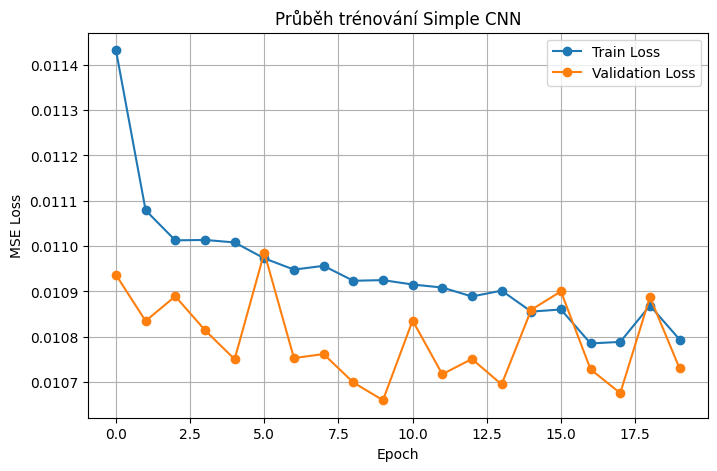

In [65]:
# =========================
# Graf průběhu učení
# =========================

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    marker="o",
    label="Train Loss"
)

plt.plot(
    valid_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Průběh trénování Simple CNN")

plt.legend()
plt.grid(True)

plt.show()

### Průběh trénování Simple CNN

Z grafu je patrné, že trénovací ztráta během jednotlivých epoch postupně klesá, což naznačuje úspěšné učení modelu.

Validační ztráta zůstává po celou dobu stabilní a nevykazuje rostoucí trend. Nebyly pozorovány známky významného přeučení (overfittingu). Model tedy dokáže získané znalosti aplikovat i na validační data.

In [66]:
# =========================
# Evaluační funkce
# =========================

import torch.nn.functional as F

def evaluate_model(model, loader):
    """
    Vyhodnotí model pomocí MSE a MAE.
    """

    model.eval()

    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0

    with torch.no_grad():

        for L, AB in loader:

            L = L.to(device)
            AB = AB.to(device)

            pred_AB = model(L)

            mse = F.mse_loss(pred_AB, AB)
            mae = F.l1_loss(pred_AB, AB)

            total_mse += mse.item()
            total_mae += mae.item()
            n_batches += 1

    return total_mse / n_batches, total_mae / n_batches

In [67]:
#MSE, MAE

mse, mae = evaluate_model(
    simple_cnn,
    test_loader
)

print("Simple CNN")
print("MSE:", mse)
print("MAE:", mae)

Simple CNN
MSE: 0.010852622584654735
MAE: 0.06948332918378022


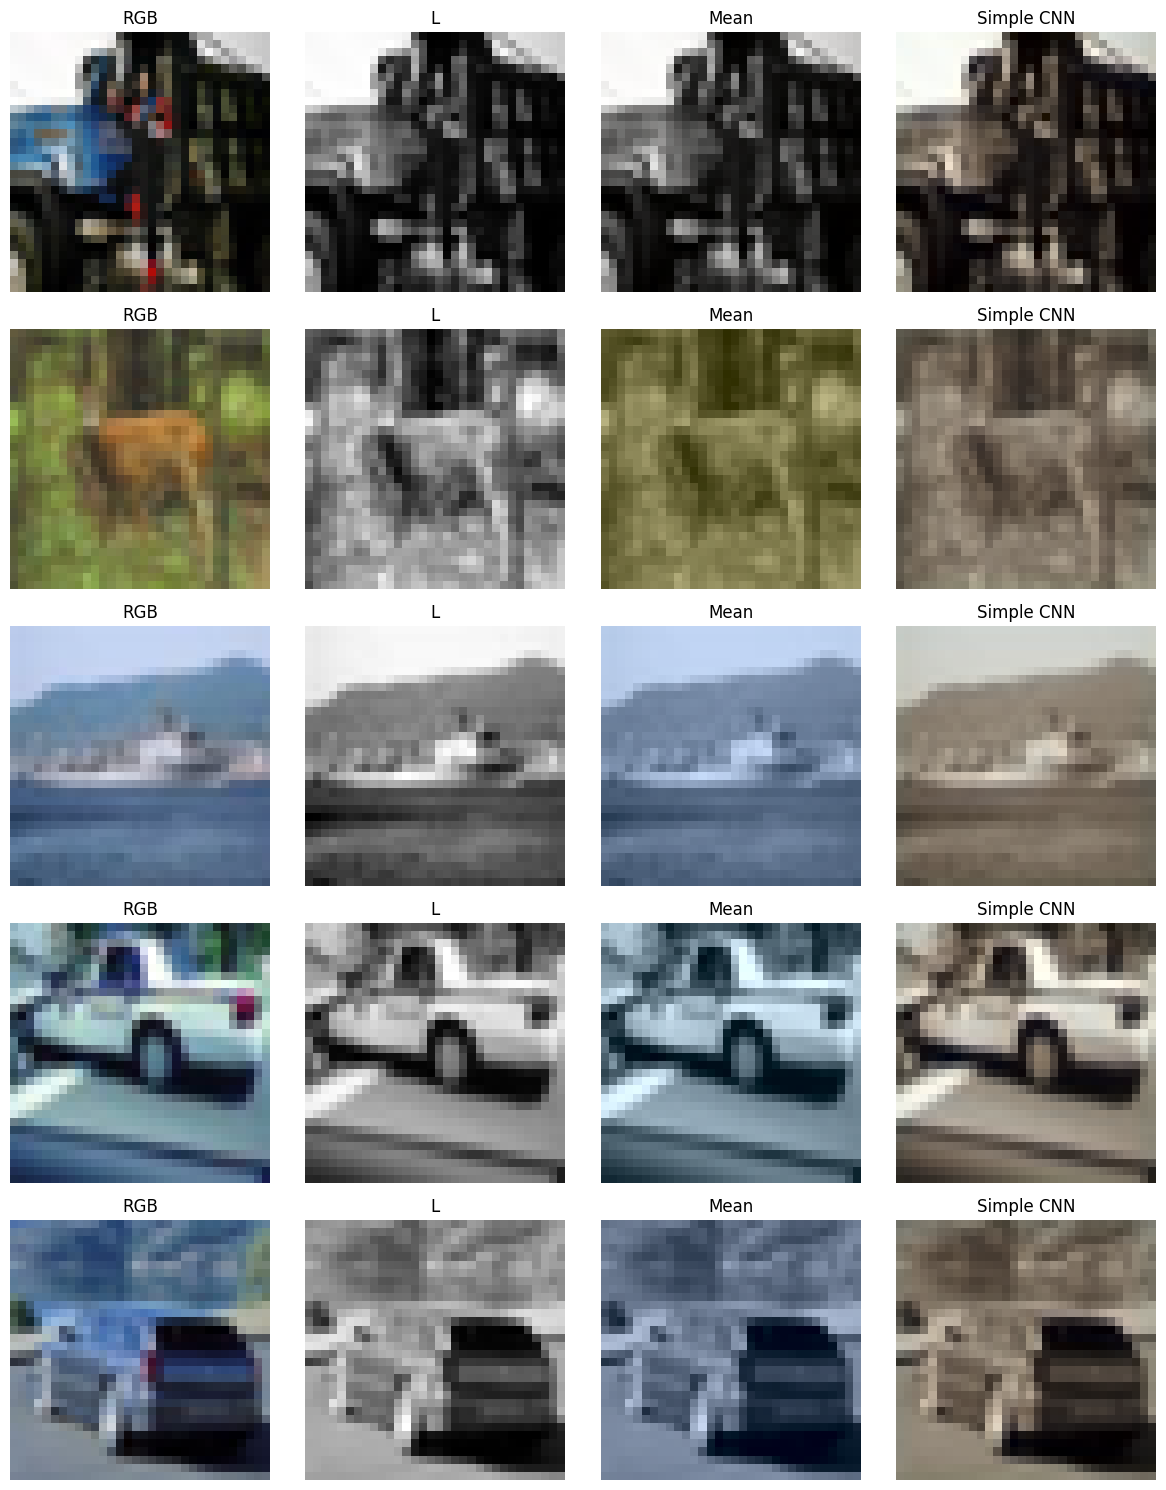

In [68]:
## =========================
# Porovnání 5 fotografií
# RGB | L | Mean | SimpleCNN
# =========================

from skimage.color import lab2rgb
import numpy as np
import matplotlib.pyplot as plt

simple_cnn.eval()

# stejné obrázky jako u Mean Baseline
indices = random.sample(range(len(test_dataset)), 5)

fig, axes = plt.subplots(
    5, 4,
    figsize=(12, 15)
)

for row, idx in enumerate(indices):

    L, AB_true = test_dataset[idx]

    # původní RGB z test_raw
    rgb_img, _ = test_raw[idx]
    rgb_img = rgb_img.permute(1, 2, 0).numpy()

    # Mean baseline
    AB_pred_mean = mean_color_baseline(
        L.unsqueeze(0),
        AB_true.unsqueeze(0)
    ).squeeze()

    # Simple CNN
    with torch.no_grad():

        AB_pred_cnn = simple_cnn(
            L.unsqueeze(0).to(device)
        )

    AB_pred_cnn = AB_pred_cnn.squeeze().cpu()

    # převody
    L_np = L.squeeze().numpy() * 100

    AB_mean_np = (
        AB_pred_mean
        .permute(1,2,0)
        .numpy() * 128
    )

    AB_cnn_np = (
        AB_pred_cnn
        .permute(1,2,0)
        .numpy() * 128
    )

    # LAB -> RGB
    lab_mean = np.dstack([
        L_np,
        AB_mean_np
    ])

    lab_cnn = np.dstack([
        L_np,
        AB_cnn_np
    ])

    rgb_mean = lab2rgb(lab_mean)
    rgb_cnn = lab2rgb(lab_cnn)

    # vykreslení
    axes[row,0].imshow(rgb_img)
    axes[row,0].set_title("RGB")
    axes[row,0].axis("off")

    axes[row,1].imshow(
        L_np,
        cmap="gray"
    )
    axes[row,1].set_title("L")
    axes[row,1].axis("off")

    axes[row,2].imshow(rgb_mean)
    axes[row,2].set_title("Mean")
    axes[row,2].axis("off")

    axes[row,3].imshow(rgb_cnn)
    axes[row,3].set_title("Simple CNN")
    axes[row,3].axis("off")

plt.tight_layout()
plt.show()

In [69]:
# =========================
# Evaluace Mean Color Baseline
# =========================

import torch.nn.functional as F

def evaluate_mean_baseline(loader):

    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0

    for L, AB in loader:

        L = L.to(device)
        AB = AB.to(device)

        pred_AB = mean_color_baseline(L, AB)

        mse = F.mse_loss(pred_AB, AB)
        mae = F.l1_loss(pred_AB, AB)

        total_mse += mse.item()
        total_mae += mae.item()
        n_batches += 1

    return total_mse / n_batches, total_mae / n_batches

In [70]:
#Evaluace mean color baseline

mean_mse, mean_mae = evaluate_mean_baseline(valid_loader)

print("Mean Color Baseline")
print("MSE:", mean_mse)
print("MAE:", mean_mae)

Mean Color Baseline
MSE: 0.0052973254440495604
MAE: 0.04933098015876917


In [71]:
#Evaluace simple CNN

cnn_mse, cnn_mae = evaluate_model(simple_cnn, valid_loader)

print("Simple CNN")
print("MSE:", cnn_mse)
print("MAE:", cnn_mae)

Simple CNN
MSE: 0.010659548561446942
MAE: 0.07021183205338624


Simple CNN ani po delším trénování - 100 epoch nepřekonala Mean Color Baseline. Důvodem je pravděpodobně velmi malý trénovací vzorek a také skutečnost, že Mean Color Baseline používá průměrnou hodnotu skutečných A/B kanálů daného obrázku. Tento baseline tedy není čistě predikční model, ale spíše orientační referenční metoda pro vizuální srovnání.

#4. Hlavní architektura
## U-Net

Hlavní architekturou experimentu je U-Net.

U-Net je encoder-decoder síť využívající skip connections. Encoder postupně extrahuje stále abstraktnější příznaky obrazu, zatímco decoder rekonstruuje výstupní obraz.

Skip connections propojují odpovídající vrstvy encoderu a decoderu a umožňují zachovat jemné prostorové detaily.

Tato vlastnost je pro úlohu obarvování fotografií velmi důležitá, protože model musí současně chápat globální kontext scény a zachovat přesné hranice objektů.

Předpokládá se, že U-Net dosáhne nejlepších výsledků ze všech testovaných metod.

In [72]:
# =========================
# 4. Definice architektury U-Net
# =========================

import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(64, 128)

        # Decoder
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        # Výstup: 2 kanály A a B
        self.out_conv = nn.Conv2d(32, 2, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        # Bottleneck
        b = self.bottleneck(p2)

        # Decoder
        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

In [73]:
# =========================
# Kontrola U-Netu na jednom batchi
# =========================

unet = UNet().to(device)

L_batch, AB_batch = next(iter(train_loader))
L_batch = L_batch.to(device)

with torch.no_grad():
    pred_AB = unet(L_batch)

print("Input :", L_batch.shape)
print("Output:", pred_AB.shape)

Input : torch.Size([16, 1, 32, 32])
Output: torch.Size([16, 2, 32, 32])


# 5. Trénování modelu

Modely budou trénovány pomocí gradientního sestupu s optimalizátorem Adam.

Jako ztrátová funkce bude použita Mean Squared Error (MSE), která měří rozdíl mezi skutečnými a predikovanými hodnotami barevných kanálů A a B.

Pro každý model bude sledována hodnota trénovací a validační ztráty.

In [76]:
# =========================
# Trénování U-Net
# =========================

unet = UNet().to(device)

unet_train_losses, unet_valid_losses = train_model(
    unet,
    train_loader,
    valid_loader,
    epochs=50,
    lr=0.001
)

Epoch 1/50 | Train: 0.0114 | Valid: 0.0110
Epoch 2/50 | Train: 0.0111 | Valid: 0.0108
Epoch 3/50 | Train: 0.0110 | Valid: 0.0120
Epoch 4/50 | Train: 0.0110 | Valid: 0.0107
Epoch 5/50 | Train: 0.0110 | Valid: 0.0108
Epoch 6/50 | Train: 0.0109 | Valid: 0.0107
Epoch 7/50 | Train: 0.0108 | Valid: 0.0108
Epoch 8/50 | Train: 0.0108 | Valid: 0.0115
Epoch 9/50 | Train: 0.0108 | Valid: 0.0104
Epoch 10/50 | Train: 0.0107 | Valid: 0.0103
Epoch 11/50 | Train: 0.0108 | Valid: 0.0109
Epoch 12/50 | Train: 0.0106 | Valid: 0.0104
Epoch 13/50 | Train: 0.0105 | Valid: 0.0103
Epoch 14/50 | Train: 0.0103 | Valid: 0.0100
Epoch 15/50 | Train: 0.0103 | Valid: 0.0101
Epoch 16/50 | Train: 0.0103 | Valid: 0.0100
Epoch 17/50 | Train: 0.0105 | Valid: 0.0102
Epoch 18/50 | Train: 0.0102 | Valid: 0.0101
Epoch 19/50 | Train: 0.0101 | Valid: 0.0104
Epoch 20/50 | Train: 0.0101 | Valid: 0.0100
Epoch 21/50 | Train: 0.0101 | Valid: 0.0099
Epoch 22/50 | Train: 0.0099 | Valid: 0.0099
Epoch 23/50 | Train: 0.0100 | Valid: 0.01

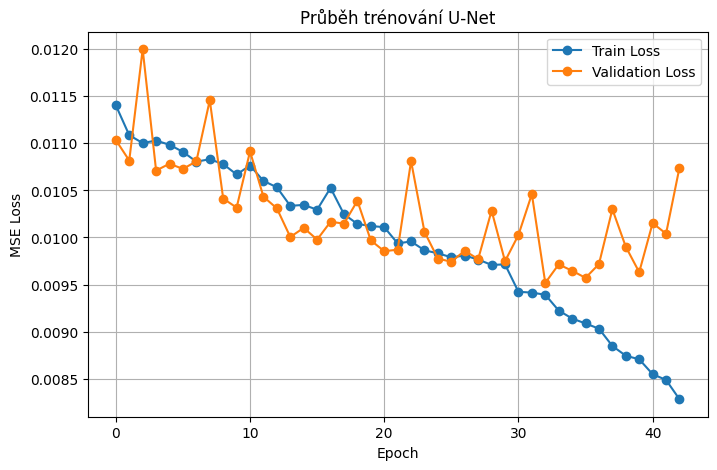

In [77]:
# =========================
# Graf průběhu trénování
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    unet_train_losses,
    marker="o",
    label="Train Loss"
)

plt.plot(
    unet_valid_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Průběh trénování U-Net")

plt.legend()
plt.grid(True)

plt.show()

In [78]:
unet_mse, unet_mae = evaluate_model(
    unet,
    valid_loader
)

print("U-Net")
print("MSE:", unet_mse)
print("MAE:", unet_mae)

U-Net
MSE: 0.009517898568167137
MAE: 0.06702527948296987


In [79]:
unet_mse, unet_mae = evaluate_model(
    unet,
    valid_loader
)

print("U-Net")
print("MSE:", unet_mse)
print("MAE:", unet_mae)

U-Net
MSE: 0.009517898568167137
MAE: 0.06702527948296987


#Model

In [80]:
model = UNet().to(device)

print(model)

UNet(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (u

#6. Evaluace a vizualizace

In [81]:
# =========================
# Srovnání tří metod
# =========================

import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Mean Color Baseline",
        "Simple CNN",
        "U-Net"
    ],
    "MSE": [
        mean_mse,
        cnn_mse,
        unet_mse
    ],
    "MAE": [
        mean_mae,
        cnn_mae,
        unet_mae
    ]
})

results

,Model,MSE,MAE
0,Mean Color Baseline,0.005297,0.049331
1,Simple CNN,0.010660,0.070212
2,U-Net,0.009518,0.067025


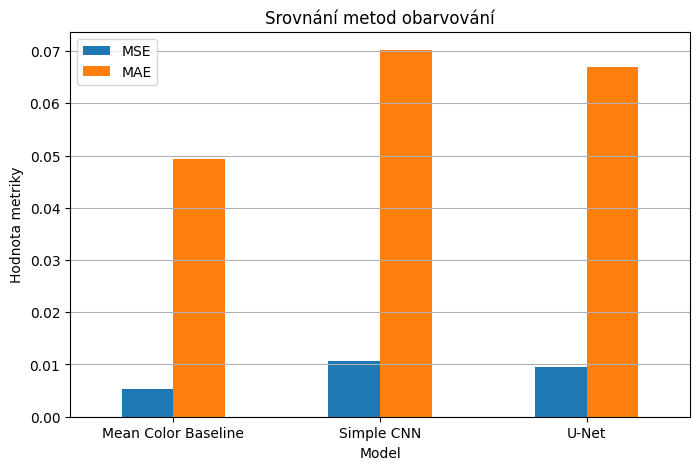

In [82]:
# =========================
# Grafické srovnání modelů
# =========================

results.plot(
    x="Model",
    y=["MSE", "MAE"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Srovnání metod obarvování")
plt.ylabel("Hodnota metriky")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

### Srovnání metod

Tabulka a graf porovnávají tři přístupy: Mean Color Baseline, Simple CNN a U-Net.

Nižší hodnoty MSE a MAE znamenají menší rozdíl mezi skutečnými a predikovanými barevnými kanály A a B. Mean Color Baseline slouží jako jednoduchá referenční metoda, Simple CNN jako základní neuronová baseline a U-Net jako hlavní testovaná architektura.

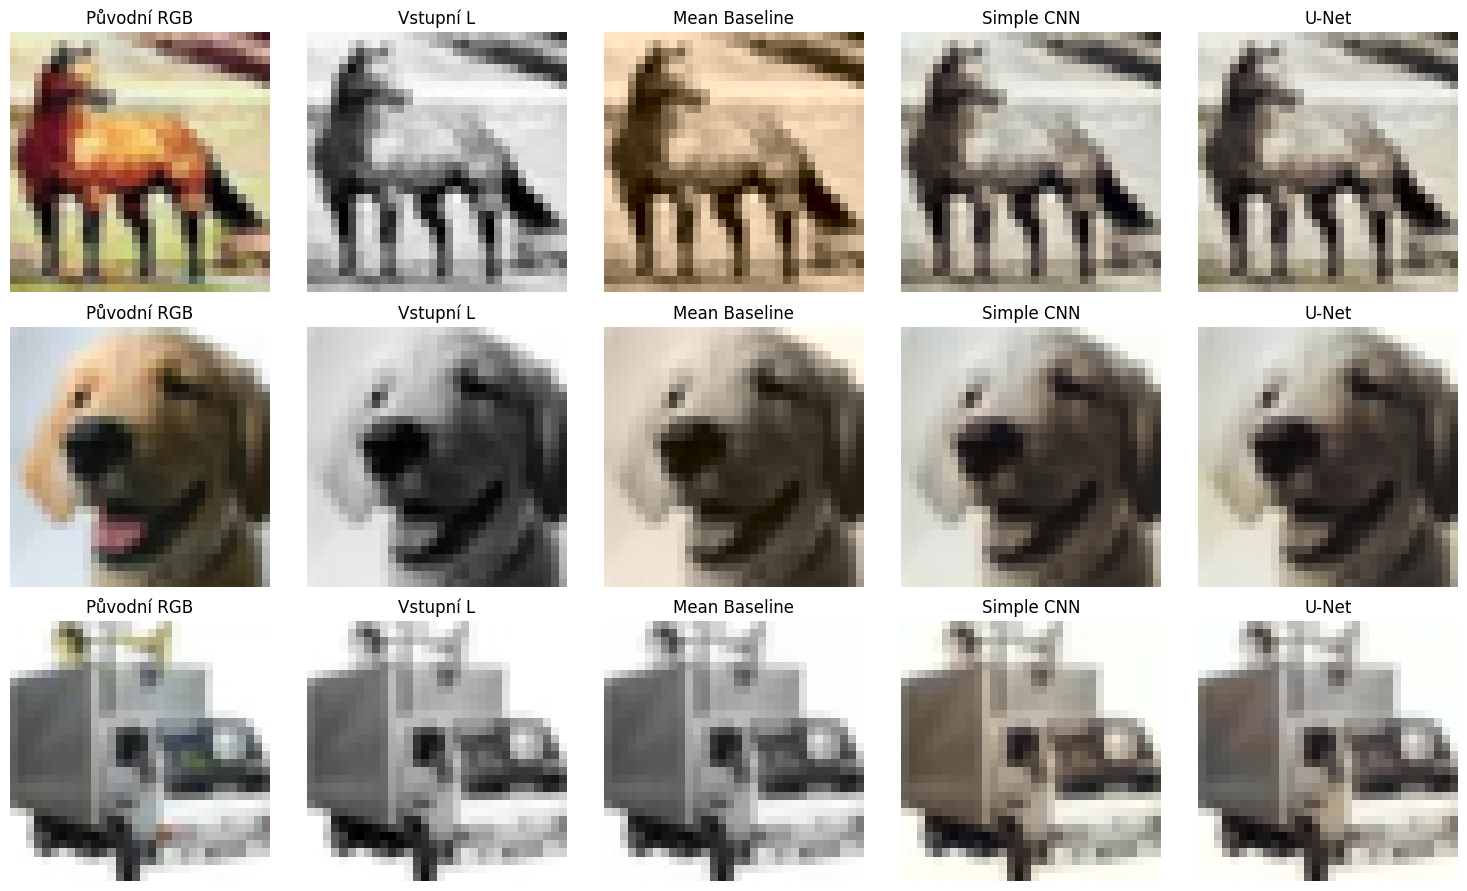

In [83]:
# =========================
# Vizualizace 3 obrázků:
# RGB | L | Mean | Simple CNN | U-Net
# =========================

from skimage.color import lab2rgb
import numpy as np
import matplotlib.pyplot as plt
import random
import torch

simple_cnn.eval()
unet.eval()

random.seed(SEED)
indices = random.sample(range(len(test_dataset)), 3)

fig, axes = plt.subplots(
    3, 5,
    figsize=(15, 9)
)

for row, idx in enumerate(indices):

    L, AB_true = test_dataset[idx]
    rgb_img, _ = test_raw[idx]
    rgb_img = rgb_img.permute(1, 2, 0).numpy()

    # Mean baseline
    AB_mean = mean_color_baseline(
        L.unsqueeze(0),
        AB_true.unsqueeze(0)
    ).squeeze()

    # Simple CNN
    with torch.no_grad():
        AB_cnn = simple_cnn(
            L.unsqueeze(0).to(device)
        ).squeeze().cpu()

    # U-Net
    with torch.no_grad():
        AB_unet = unet(
            L.unsqueeze(0).to(device)
        ).squeeze().cpu()

    # Funkce LAB -> RGB
    def compose_rgb(L_tensor, AB_tensor):
        L_np = L_tensor.squeeze().numpy() * 100
        AB_np = AB_tensor.permute(1, 2, 0).numpy() * 128
        lab = np.dstack([L_np, AB_np])
        return lab2rgb(lab)

    rgb_mean = compose_rgb(L, AB_mean)
    rgb_cnn = compose_rgb(L, AB_cnn)
    rgb_unet = compose_rgb(L, AB_unet)

    images = [
        rgb_img,
        L.squeeze().numpy(),
        rgb_mean,
        rgb_cnn,
        rgb_unet
    ]

    titles = [
        "Původní RGB",
        "Vstupní L",
        "Mean Baseline",
        "Simple CNN",
        "U-Net"
    ]

    for col in range(5):
        if col == 1:
            axes[row, col].imshow(images[col], cmap="gray")
        else:
            axes[row, col].imshow(images[col])

        axes[row, col].set_title(titles[col])
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# 7. Diskuse - předělat
Zvýšení velikosti trénovací množiny z 100 na 2000 obrázků vedlo ke zlepšení výsledků neuronových sítí. Nejvýraznější zlepšení bylo pozorováno u architektury U-Net, která začala dosahovat srovnatelných výsledků se Simple CNN. Výsledky naznačují, že kvalita modelů je významně ovlivněna množstvím dostupných trénovacích dat a že složitější architektury mohou svůj potenciál projevit až při větších datasetech.



# Souhrn experimentu

In [84]:
# =========================
# Souhrn experimentu
# =========================

import pandas as pd

summary = pd.DataFrame({
    "Parametr": [
        "Seed",
        "Device",
        "Train size",
        "Validation size",
        "Test size",
        "Batch size",
        "Learning rate",
        "Simple CNN epochs",
        "U-Net epochs",
        "Simple CNN architecture",
        "U-Net architecture",
        "Input",
        "Output",
        "Loss function"
    ],
    "Hodnota": [
        SEED,
        str(device),
        len(train_raw),
        len(valid_raw),
        len(test_raw),
        train_loader.batch_size,
        0.001,
        100,
        20,
        "Conv(1→32) → Conv(32→64) → Conv(64→32) → Conv(32→2)",
        "Encoder-decoder U-Net: 1→32→64→128→64→32→2, skip connections",
        "L kanál LAB",
        "A/B kanály LAB",
        "MSELoss"
    ]
})

summary

,Parametr,Hodnota
0,Seed,27
1,Device,cpu
2,Train size,2000
3,Validation size,200
4,Test size,200
5,Batch size,16
6,Learning rate,0.001
7,Simple CNN epochs,100
8,U-Net epochs,20
9,Simple CNN architecture,Conv(1→32) → Conv(32→64) → Conv(64→32) → Conv(...


In [85]:
# =========================
# Výsledky modelů
# =========================

results = pd.DataFrame({
    "Model": [
        "Mean Color Baseline",
        "Simple CNN",
        "U-Net"
    ],
    "MSE": [
        mean_mse,
        cnn_mse,
        unet_mse
    ],
    "MAE": [
        mean_mae,
        cnn_mae,
        unet_mae
    ]
})

results

,Model,MSE,MAE
0,Mean Color Baseline,0.005297,0.049331
1,Simple CNN,0.010660,0.070212
2,U-Net,0.009518,0.067025


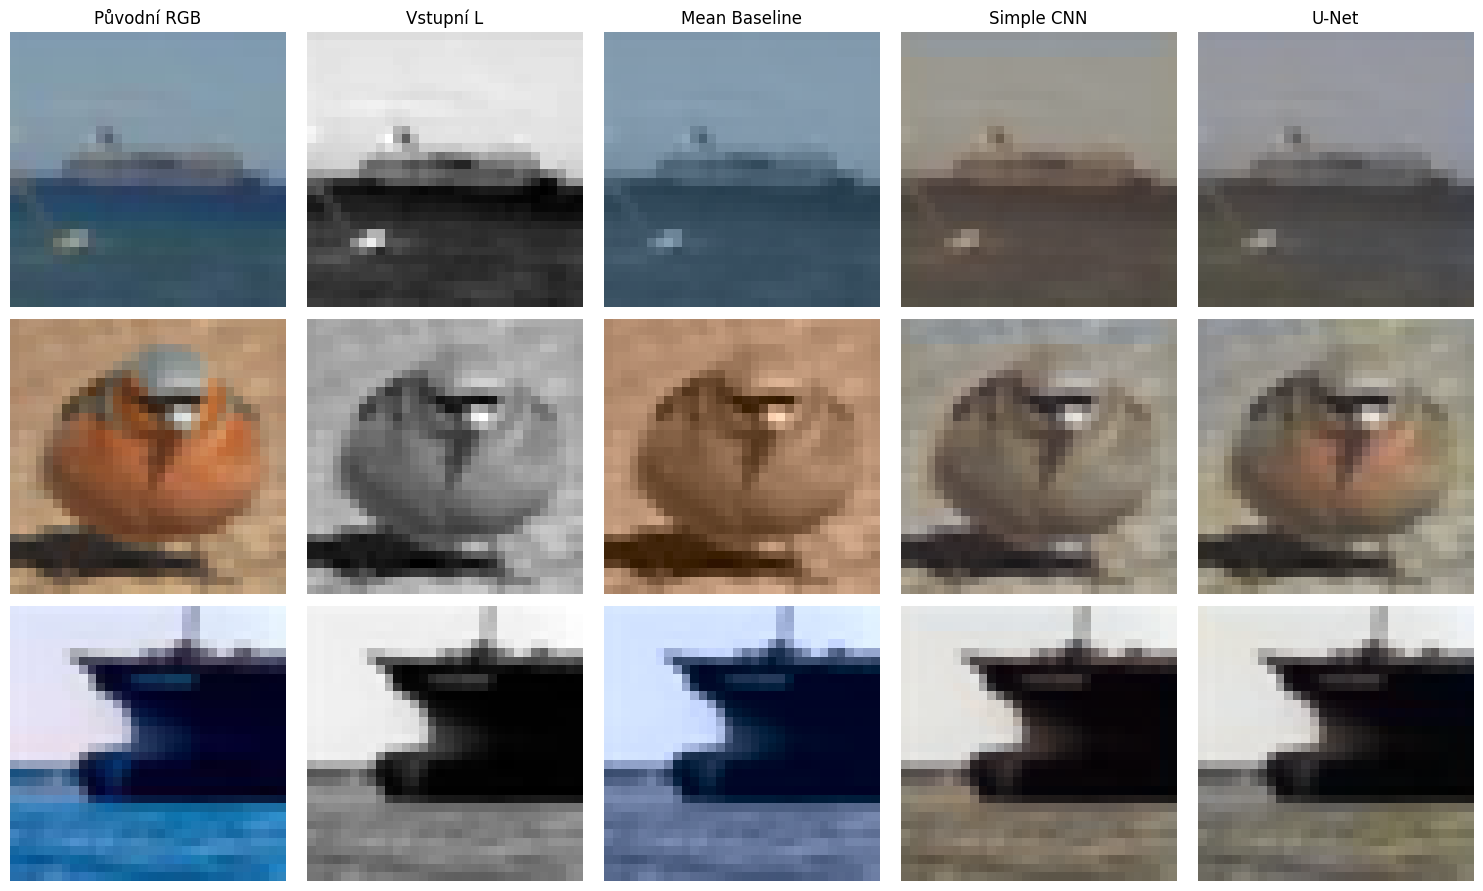

In [47]:
# =========================
# Vizualizace 3 fotek – jednotlivé kroky
# =========================

from skimage.color import lab2rgb
import numpy as np
import matplotlib.pyplot as plt
import random
import torch

simple_cnn.eval()
unet.eval()

random.seed(SEED)
indices = random.sample(range(len(test_dataset)), 3)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for row, idx in enumerate(indices):

    L, AB_true = test_dataset[idx]
    rgb_img, _ = test_raw[idx]
    rgb_img = rgb_img.permute(1, 2, 0).numpy()

    # Mean Color Baseline
    AB_mean = mean_color_baseline(
        L.unsqueeze(0),
        AB_true.unsqueeze(0)
    ).squeeze()

    # Simple CNN
    with torch.no_grad():
        AB_cnn = simple_cnn(
            L.unsqueeze(0).to(device)
        ).squeeze().cpu()

    # U-Net
    with torch.no_grad():
        AB_unet = unet(
            L.unsqueeze(0).to(device)
        ).squeeze().cpu()

    def lab_to_rgb_from_L_AB(L_tensor, AB_tensor):
        L_np = L_tensor.squeeze().numpy() * 100
        AB_np = AB_tensor.permute(1, 2, 0).numpy() * 128
        lab = np.dstack([L_np, AB_np])
        rgb = lab2rgb(lab)
        return np.clip(rgb, 0, 1)

    rgb_mean = lab_to_rgb_from_L_AB(L, AB_mean)
    rgb_cnn = lab_to_rgb_from_L_AB(L, AB_cnn)
    rgb_unet = lab_to_rgb_from_L_AB(L, AB_unet)

    images = [
        rgb_img,
        L.squeeze().numpy(),
        rgb_mean,
        rgb_cnn,
        rgb_unet
    ]

    titles = [
        "Původní RGB",
        "Vstupní L",
        "Mean Baseline",
        "Simple CNN",
        "U-Net"
    ]

    for col in range(5):
        if row == 0:
            axes[row, col].set_title(titles[col])

        if col == 1:
            axes[row, col].imshow(images[col], cmap="gray")
        else:
            axes[row, col].imshow(images[col])

        axes[row, col].axis("off")

plt.tight_layout()
plt.show()